In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

## Members

user information. Note that not every user in the dataset is available.

    msno
    city
    bd: age. Note: this column has outlier values ranging from -7000 to 2015, please use your judgement.
    gender
    registered_via: registration method
    registration_init_time: format %Y%m%d
    expiration_date: format %Y%m%d, taken as a snapshot at which the member.csv is extracted. Not representing the actual churn behavior.


In [4]:
df_members = pd.read_csv('../data/raw/members_v3.csv')

In [5]:
df_members.head()

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [10]:
df_members.shape

(6769473, 6)

In [18]:
df_members["city"] = df_members.city.astype('category')

<Axes: >

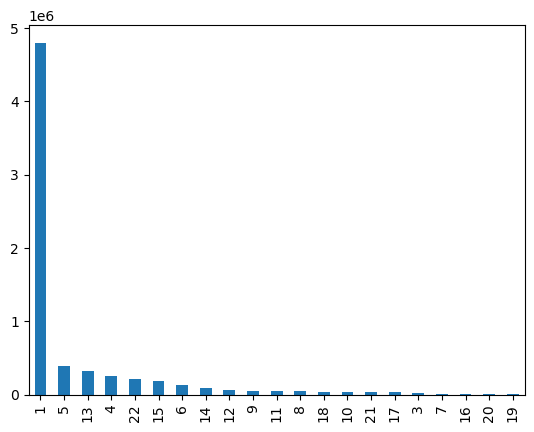

In [22]:
df_members.city.value_counts().plot(kind="bar")

In [39]:
df_members['registered_via'] = df_members.registered_via.astype('category')

<Axes: >

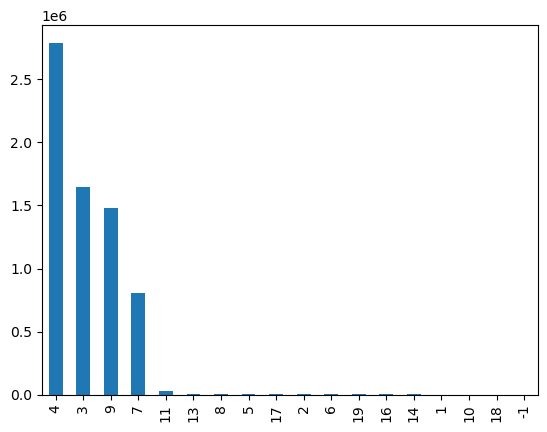

In [41]:
df_members['registered_via'].value_counts().plot(kind='bar')

<Axes: >

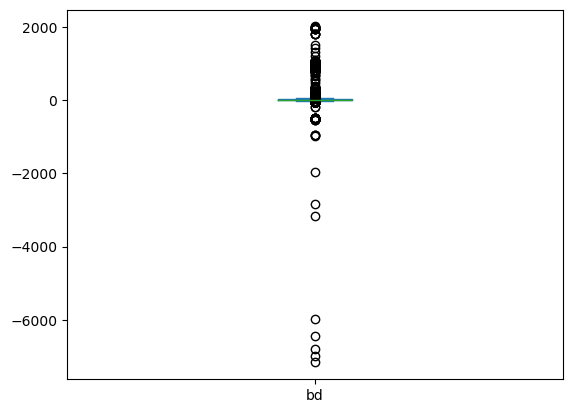

In [26]:
df_members.bd.plot(kind="box")

In [29]:
sum(df_members['bd'] < 0) / df_members.shape[0] # tiny percentage

4.047582433669504e-05

In [31]:
sum(df_members['bd'] > 110) / df_members.shape[0] # another small percentage

0.00036383925307036455

In [36]:
df['bd'] = np.where((df['bd'] > 110) | (df['bd'] < 0), np.nan, df['bd'])

In [38]:
sum(df['bd'].isna()) / df.shape[0]

0.0004043150774070596

## Logs

daily user logs describing listening behaviors of a user. Data collected until 2/28/2017.

    msno: user id
    date: format %Y%m%d
    num_25: # of songs played less than 25% of the song length
    num_50: # of songs played between 25% to 50% of the song length
    num_75: # of songs played between 50% to 75% of of the song length
    num_985: # of songs played between 75% to 98.5% of the song length
    num_100: # of songs played over 98.5% of the song length
    num_unq: # of unique songs played
    total_secs: total seconds played


In [7]:
df_logs = pd.read_csv('../data/raw/user_logs_v2.csv')

In [8]:
df_logs.head()

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.273
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337
3,ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=,20170331,176,4,2,2,19,191,7100.454
4,EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=,20170331,2,1,0,1,112,93,28401.558


In [9]:
df_logs.shape

(18396362, 9)

In [11]:
df_logs['msno'].value_counts()

u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=    31
0qLiw20oFg1MBocPTyj3qu37+yWf7UGNz0zekeSpcaM=    31
YWa5GpzNoF6u0117DB+4HgEuBp3IuBxvN+6I/62qoVM=    31
m16fMSTcxvSmxE6dF6XW1n0a9EtWsSz2mz9bfRsZ58w=    31
OI0Vbi3v3D1GOPP/7NTaJrK8vOxSikGirFE+qE2LMYY=    31
                                                ..
U/A6equ77WxREwyiLAUcX6ZCmotzeE02NSsEsXtC3rw=     1
87rzAfuRBvhMWKnO3db3Y0N7gAJh3UW+XtMjQWMhPd0=     1
A1v6d1GV5FaesozhjKKDUF5EDY4NXQD5q0rV2gw5ZvM=     1
jnD1ztRJZku8+nZnM1lvinSVWyzDPgygKEV7lLUIEsk=     1
uLsXcs3ztNgyl5ipvAWS3hcSlQ5bI7OIZBCJkStHSTw=     1
Name: msno, Length: 1103894, dtype: int64

## Transactions

transactions of users up until 2/28/2017.

    msno: user id
    payment_method_id: payment method
    payment_plan_days: length of membership plan in days
    plan_list_price: in New Taiwan Dollar (NTD)
    actual_amount_paid: in New Taiwan Dollar (NTD)
    is_auto_renew
    transaction_date: format %Y%m%d
    membership_expire_date: format %Y%m%d
    is_cancel: whether or not the user canceled the membership in this transaction.


In [14]:
df_transactions = pd.read_csv("../data/raw/transactions_v2.csv")

## Train set

the train set, containing the user ids and whether they have churned.

    msno: user id
    is_churn: This is the target variable. Churn is defined as whether the user did not continue the subscription within 30 days of expiration. is_churn = 1 means churn,is_churn = 0 means renewal.


In [15]:
df_train = pd.read_csv("../data/raw/train_v2.csv")